In [ ]:
from google.colab import files
uploaded = files.upload()


Saving monthly_sales_features.csv to monthly_sales_features.csv
Saving Sample - Superstore.csv to Sample - Superstore (1).csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (14, 5)

# Load prepared features
monthly_clean = pd.read_csv('monthly_sales_features.csv', parse_dates=['ds'])

# Recreate train/test split
split_index = len(monthly_clean) - 6
train = monthly_clean.iloc[:split_index].copy()
test  = monthly_clean.iloc[split_index:].copy()

print("✅ Data loaded")
print(f"Train: {len(train)} rows | Test: {len(test)} rows")

✅ Data loaded
Train: 30 rows | Test: 6 rows


In [ ]:
!pip install statsmodels prophet --quiet
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error

print("✅ Libraries ready")

✅ Libraries ready


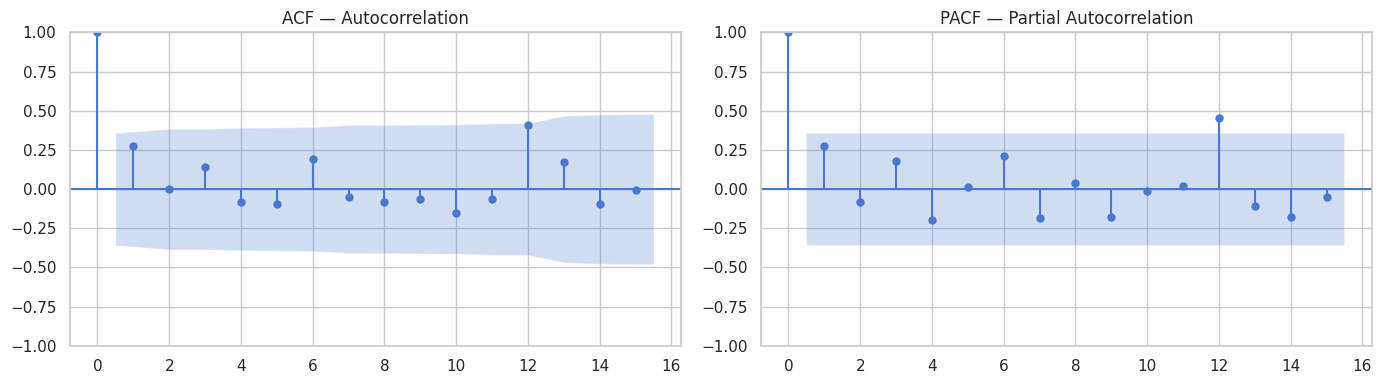

✅ Saved: acf_pacf.png


In [ ]:
ts_train = train.set_index('ds')['y']

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(ts_train,  lags=15, ax=axes[0], title='ACF — Autocorrelation')
plot_pacf(ts_train, lags=15, ax=axes[1], title='PACF — Partial Autocorrelation')
plt.tight_layout()
plt.savefig('acf_pacf.png', dpi=150)
plt.show()
print("✅ Saved: acf_pacf.png")

In [ ]:
# ARIMA(p, d, q) — (1,1,1) is a solid starting point for monthly sales
arima_model = ARIMA(ts_train, order=(1, 1, 1))
arima_result = arima_model.fit()

print(arima_result.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   30
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -330.570
Date:                Wed, 10 Jun 2026   AIC                            667.140
Time:                        09:47:13   BIC                            671.242
Sample:                    01-01-2015   HQIC                           668.425
                         - 06-01-2017                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2133      0.323      0.661      0.509      -0.419       0.846
ma.L1         -0.8132      0.171     -4.749      0.000      -1.149      -0.478
sigma2       5.71e+08   6.11e-12   9.34e+19      0.0

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


=== ARIMA Results ===
MAE  : $31,095
RMSE : $37,098
MAPE : 34.95%


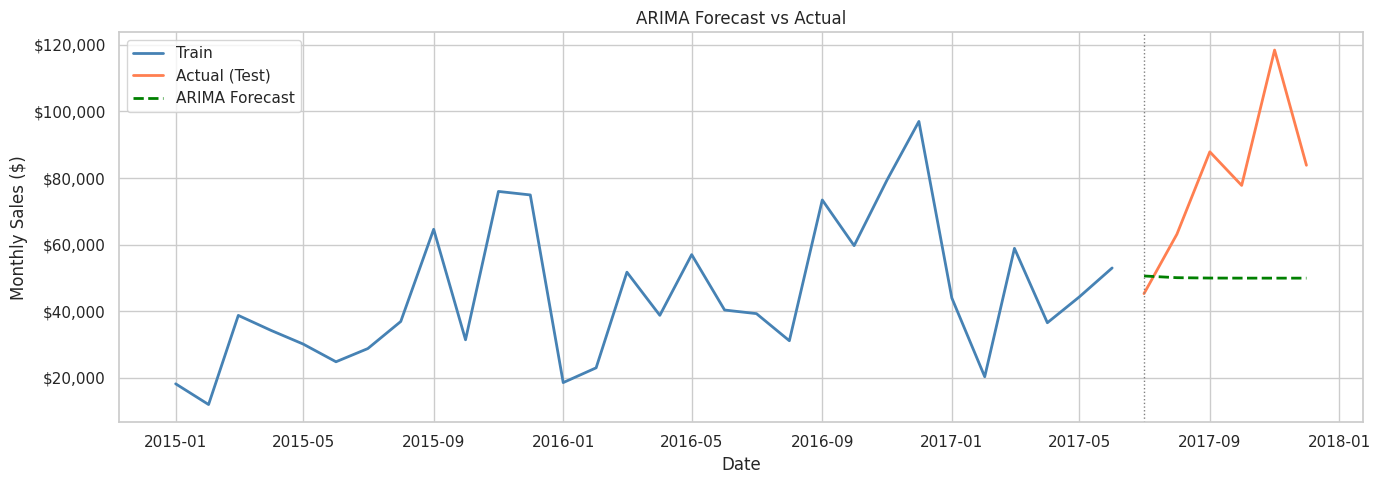

✅ Saved: arima_forecast.png


In [ ]:
# Forecast 6 months (same as test set)
arima_forecast = arima_result.forecast(steps=6)
arima_forecast.index = test['ds'].values

# Metrics
arima_mae  = mean_absolute_error(test['y'], arima_forecast)
arima_rmse = np.sqrt(mean_squared_error(test['y'], arima_forecast))
arima_mape = np.mean(np.abs((test['y'].values - arima_forecast.values) / test['y'].values)) * 100

print("=== ARIMA Results ===")
print(f"MAE  : ${arima_mae:,.0f}")
print(f"RMSE : ${arima_rmse:,.0f}")
print(f"MAPE : {arima_mape:.2f}%")

# Plot
plt.figure(figsize=(14, 5))
plt.plot(train['ds'], train['y'],       label='Train',         color='steelblue', linewidth=2)
plt.plot(test['ds'],  test['y'],        label='Actual (Test)', color='coral',     linewidth=2)
plt.plot(test['ds'],  arima_forecast,   label='ARIMA Forecast',color='green',     linewidth=2, linestyle='--')
plt.axvline(test['ds'].iloc[0], color='gray', linestyle=':', linewidth=1)
plt.title('ARIMA Forecast vs Actual')
plt.xlabel('Date')
plt.ylabel('Monthly Sales ($)')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.legend()
plt.tight_layout()
plt.savefig('arima_forecast.png', dpi=150)
plt.show()
print("✅ Saved: arima_forecast.png")

In [ ]:
# Prophet needs columns named exactly 'ds' and 'y'
prophet_train = train[['ds', 'y']].copy()

prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode='additive'
)
prophet_model.fit(prophet_train)
print("✅ Prophet model fitted")

INFO:prophet:n_changepoints greater than number of observations. Using 23.


✅ Prophet model fitted


=== Prophet Results ===
MAE  : $14,973
RMSE : $17,478
MAPE : 17.86%


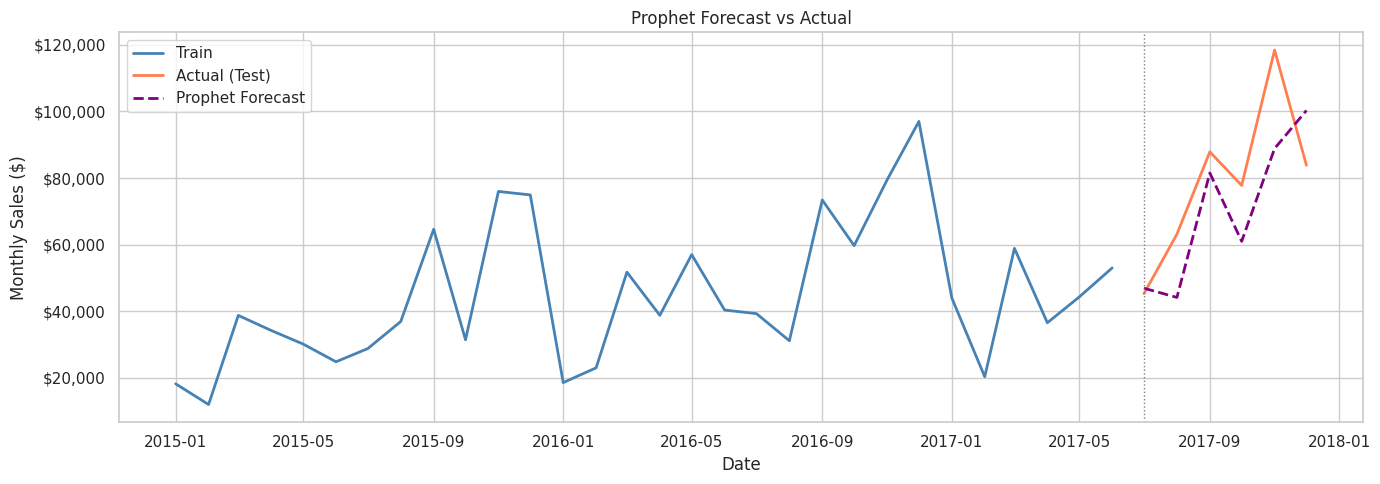

✅ Saved: prophet_forecast.png


In [ ]:
# Create future dataframe for test period
future = prophet_model.make_future_dataframe(periods=6, freq='MS')
prophet_forecast = prophet_model.predict(future)

# Extract test period predictions
prophet_test_pred = prophet_forecast[prophet_forecast['ds'].isin(test['ds'])]['yhat'].values

# Metrics
prophet_mae  = mean_absolute_error(test['y'], prophet_test_pred)
prophet_rmse = np.sqrt(mean_squared_error(test['y'], prophet_test_pred))
prophet_mape = np.mean(np.abs((test['y'].values - prophet_test_pred) / test['y'].values)) * 100

print("=== Prophet Results ===")
print(f"MAE  : ${prophet_mae:,.0f}")
print(f"RMSE : ${prophet_rmse:,.0f}")
print(f"MAPE : {prophet_mape:.2f}%")

# Plot
plt.figure(figsize=(14, 5))
plt.plot(train['ds'], train['y'],          label='Train',           color='steelblue', linewidth=2)
plt.plot(test['ds'],  test['y'],           label='Actual (Test)',   color='coral',     linewidth=2)
plt.plot(test['ds'],  prophet_test_pred,   label='Prophet Forecast',color='purple',    linewidth=2, linestyle='--')
plt.axvline(test['ds'].iloc[0], color='gray', linestyle=':', linewidth=1)
plt.title('Prophet Forecast vs Actual')
plt.xlabel('Date')
plt.ylabel('Monthly Sales ($)')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.legend()
plt.tight_layout()
plt.savefig('prophet_forecast.png', dpi=150)
plt.show()
print("✅ Saved: prophet_forecast.png")

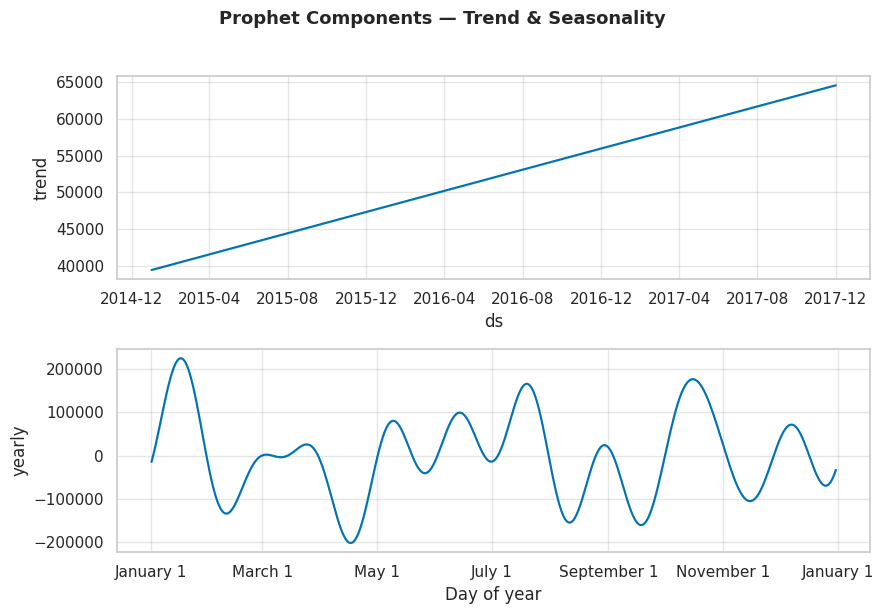

✅ Saved: prophet_components.png


In [ ]:
fig = prophet_model.plot_components(prophet_forecast)
plt.suptitle('Prophet Components — Trend & Seasonality', y=1.02, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('prophet_components.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: prophet_components.png")

In [ ]:
results = pd.DataFrame({
    'Model': ['ARIMA(1,1,1)', 'Prophet'],
    'MAE':   [arima_mae,      prophet_mae],
    'RMSE':  [arima_rmse,     prophet_rmse],
    'MAPE':  [arima_mape,     prophet_mape]
})

results['MAE']  = results['MAE'].apply(lambda x: f'${x:,.0f}')
results['RMSE'] = results['RMSE'].apply(lambda x: f'${x:,.0f}')
results['MAPE'] = results['MAPE'].apply(lambda x: f'{x:.2f}%')

print("=== Model Comparison ===")
print(results.to_string(index=False))

=== Model Comparison ===
       Model     MAE    RMSE   MAPE
ARIMA(1,1,1) $31,095 $37,098 34.95%
     Prophet $14,973 $17,478 17.86%


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

print("✅ ML libraries ready")

✅ ML libraries ready


In [ ]:
# Features we engineered in Phase 2
feature_cols = [
    'lag_1', 'lag_2', 'lag_3', 'lag_12',
    'rolling_3', 'rolling_6', 'rolling_12',
    'month_num', 'quarter', 'year', 'is_q4'
]

X_train = train[feature_cols].copy()
y_train = train['y'].copy()

X_test  = test[feature_cols].copy()
y_test  = test['y'].copy()

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("\nFeatures used:", feature_cols)

X_train shape: (30, 11)
X_test shape : (6, 11)

Features used: ['lag_1', 'lag_2', 'lag_3', 'lag_12', 'rolling_3', 'rolling_6', 'rolling_12', 'month_num', 'quarter', 'year', 'is_q4']


In [ ]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

lr_mae  = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_mape = np.mean(np.abs((y_test.values - lr_pred) / y_test.values)) * 100

print("=== Linear Regression ===")
print(f"MAE  : ${lr_mae:,.0f}")
print(f"RMSE : ${lr_rmse:,.0f}")
print(f"MAPE : {lr_mape:.2f}%")

=== Linear Regression ===
MAE  : $18,380
RMSE : $20,925
MAPE : 21.87%


In [ ]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=5,
    random_state=42
)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

rf_mae  = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_mape = np.mean(np.abs((y_test.values - rf_pred) / y_test.values)) * 100

print("=== Random Forest ===")
print(f"MAE  : ${rf_mae:,.0f}")
print(f"RMSE : ${rf_rmse:,.0f}")
print(f"MAPE : {rf_mape:.2f}%")

=== Random Forest ===
MAE  : $15,666
RMSE : $18,754
MAPE : 19.27%


In [ ]:
xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0
)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

xgb_mae  = mean_absolute_error(y_test, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_mape = np.mean(np.abs((y_test.values - xgb_pred) / y_test.values)) * 100

print("=== XGBoost ===")
print(f"MAE  : ${xgb_mae:,.0f}")
print(f"RMSE : ${xgb_rmse:,.0f}")
print(f"MAPE : {xgb_mape:.2f}%")

=== XGBoost ===
MAE  : $17,775
RMSE : $21,467
MAPE : 21.21%


In [ ]:
all_results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost',
              'ARIMA(1,1,1)', 'Prophet'],
    'MAE':   [lr_mae,  rf_mae,  xgb_mae,  31095, 14973],
    'RMSE':  [lr_rmse, rf_rmse, xgb_rmse, 37098, 17478],
    'MAPE':  [lr_mape, rf_mape, xgb_mape, 34.95, 17.86]
})

all_results = all_results.sort_values('MAPE').reset_index(drop=True)

print("=== FULL MODEL COMPARISON (sorted by MAPE) ===")
display_df = all_results.copy()
display_df['MAE']  = display_df['MAE'].apply(lambda x: f'${x:,.0f}')
display_df['RMSE'] = display_df['RMSE'].apply(lambda x: f'${x:,.0f}')
display_df['MAPE'] = display_df['MAPE'].apply(lambda x: f'{x:.2f}%')
print(display_df.to_string(index=False))

=== FULL MODEL COMPARISON (sorted by MAPE) ===
            Model     MAE    RMSE   MAPE
          Prophet $14,973 $17,478 17.86%
    Random Forest $15,666 $18,754 19.27%
          XGBoost $17,775 $21,467 21.21%
Linear Regression $18,380 $20,925 21.87%
     ARIMA(1,1,1) $31,095 $37,098 34.95%


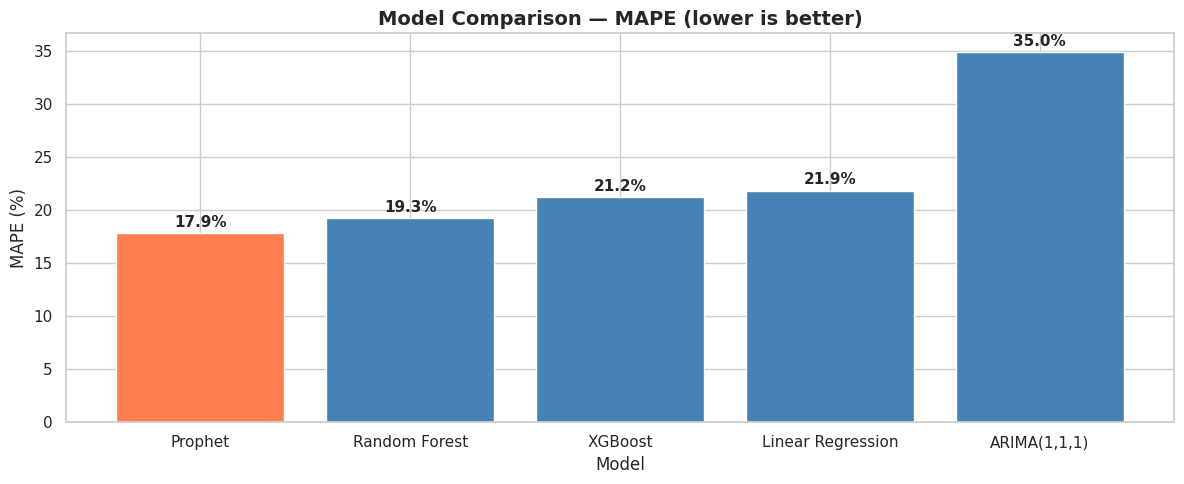

✅ Saved: model_comparison_mape.png


In [ ]:
plt.figure(figsize=(12, 5))
colors = ['coral' if m == all_results['MAPE'].min() else 'steelblue'
          for m in all_results['MAPE']]
bars = plt.bar(all_results['Model'], all_results['MAPE'], color=colors, edgecolor='white')

# Add value labels on bars
for bar, val in zip(bars, all_results['MAPE']):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             f'{val:.1f}%',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.title('Model Comparison — MAPE (lower is better)', fontsize=14, fontweight='bold')
plt.ylabel('MAPE (%)')
plt.xlabel('Model')
plt.tight_layout()
plt.savefig('model_comparison_mape.png', dpi=150)
plt.show()
print("✅ Saved: model_comparison_mape.png")

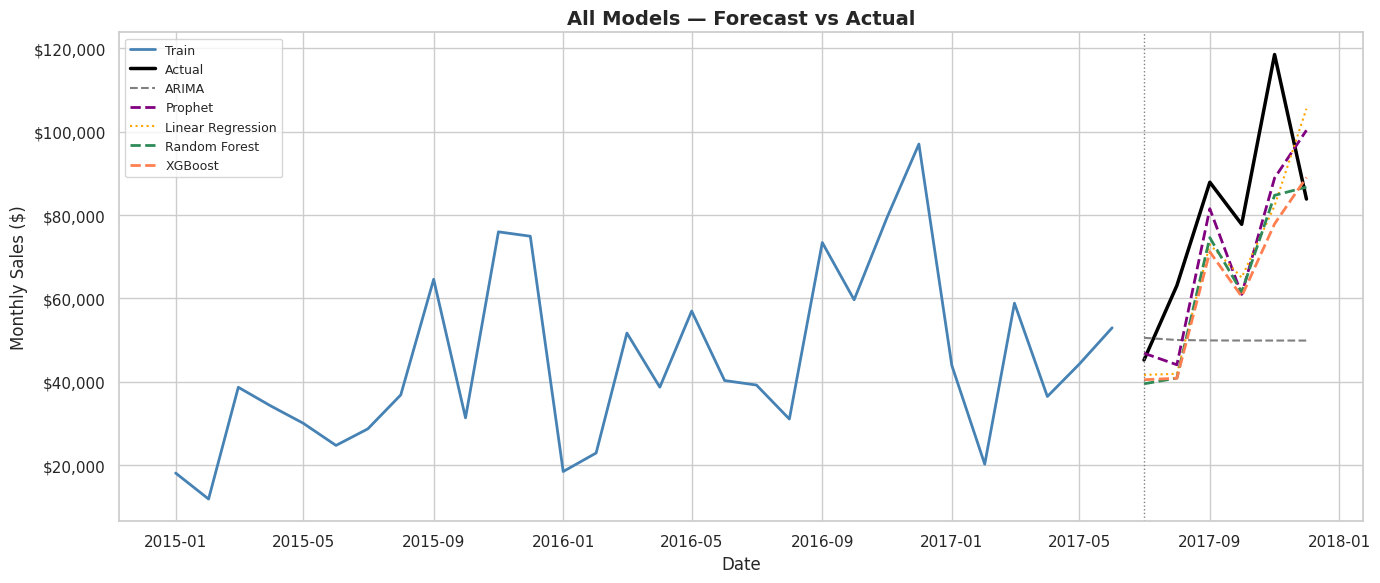

✅ Saved: all_models_forecast.png


In [ ]:
plt.figure(figsize=(14, 6))
plt.plot(train['ds'], train['y'],      label='Train',             color='steelblue',  linewidth=2)
plt.plot(test['ds'],  test['y'],       label='Actual',            color='black',      linewidth=2.5)
plt.plot(test['ds'],  arima_forecast,  label='ARIMA',             color='gray',       linewidth=1.5, linestyle='--')
plt.plot(test['ds'],  prophet_test_pred, label='Prophet',         color='purple',     linewidth=2,   linestyle='--')
plt.plot(test['ds'],  lr_pred,         label='Linear Regression', color='orange',     linewidth=1.5, linestyle=':')
plt.plot(test['ds'],  rf_pred,         label='Random Forest',     color='seagreen',   linewidth=2,   linestyle='--')
plt.plot(test['ds'],  xgb_pred,        label='XGBoost',           color='coral',      linewidth=2,   linestyle='--')

plt.axvline(test['ds'].iloc[0], color='gray', linestyle=':', linewidth=1)
plt.title('All Models — Forecast vs Actual', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Monthly Sales ($)')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('all_models_forecast.png', dpi=150)
plt.show()
print("✅ Saved: all_models_forecast.png")

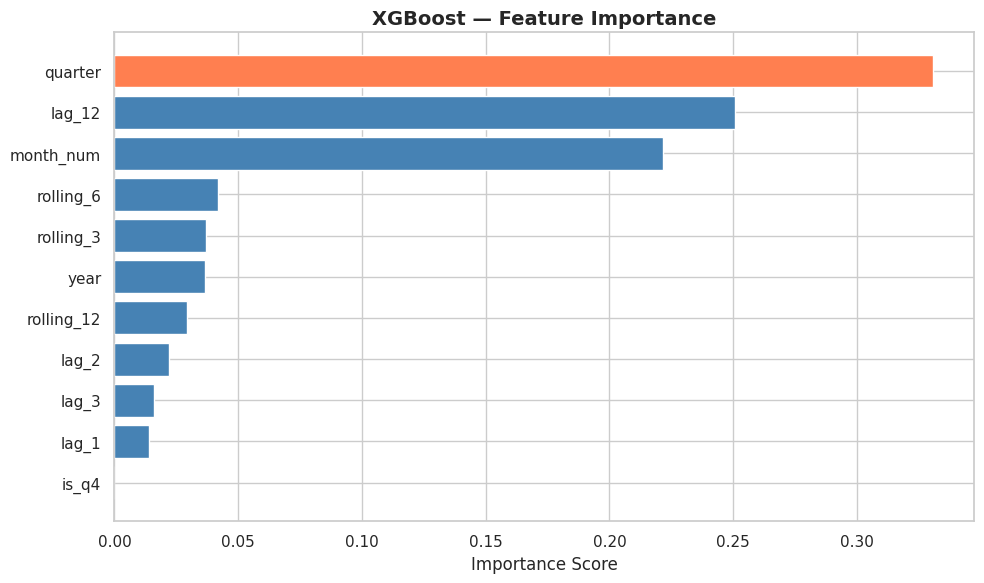

✅ Saved: feature_importance.png


In [ ]:
feat_imp = pd.Series(xgb_model.feature_importances_, index=feature_cols)
feat_imp = feat_imp.sort_values(ascending=True)

plt.figure(figsize=(10, 6))
colors = ['coral' if v == feat_imp.max() else 'steelblue' for v in feat_imp.values]
plt.barh(feat_imp.index, feat_imp.values, color=colors)
plt.title('XGBoost — Feature Importance', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()
print("✅ Saved: feature_importance.png")

In [ ]:
all_results.to_csv('model_comparison_results.csv', index=False)
print("✅ Saved: model_comparison_results.csv")

✅ Saved: model_comparison_results.csv


In [ ]:
from google.colab import files
files.download('model_comparison_results.csv')
files.download('model_comparison_mape.png')
files.download('all_models_forecast.png')
files.download('feature_importance.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files

# Original superstore data
df_raw = pd.read_csv('Sample - Superstore.csv', encoding='windows-1252')
df_raw['Order Date'] = pd.to_datetime(df_raw['Order Date'])
df_raw['YearMonth']  = df_raw['Order Date'].dt.to_period('M').dt.to_timestamp()

# Monthly actuals
monthly_actual = df_raw.groupby('YearMonth')['Sales'].sum().reset_index()
monthly_actual.columns = ['Date', 'Actual_Sales']

# Forecast comparison (test period only)
forecast_df = pd.DataFrame({
    'Date'             : test['ds'].values,
    'Actual_Sales'     : test['y'].values,
    'Prophet_Forecast' : prophet_test_pred,
    'RF_Forecast'      : rf_pred,
    'XGB_Forecast'     : xgb_pred,
    'LR_Forecast'      : lr_pred,
    'ARIMA_Forecast'   : arima_forecast.values
})

# Category & region breakdown (for dashboard filters)
cat_monthly = df_raw.groupby(['YearMonth', 'Category'])['Sales'].sum().reset_index()
cat_monthly.columns = ['Date', 'Category', 'Sales']

reg_monthly = df_raw.groupby(['YearMonth', 'Region'])['Sales'].sum().reset_index()
reg_monthly.columns = ['Date', 'Region', 'Sales']

# Save all
monthly_actual.to_csv('tableau_monthly_actual.csv', index=False)
forecast_df.to_csv('tableau_forecast_comparison.csv', index=False)
cat_monthly.to_csv('tableau_category_sales.csv', index=False)
reg_monthly.to_csv('tableau_region_sales.csv', index=False)
model_comparison_results = pd.read_csv('model_comparison_results.csv')
model_comparison_results.to_csv('tableau_model_metrics.csv', index=False)

print("✅ All Tableau files saved")

# Download all
for f in ['tableau_monthly_actual.csv', 'tableau_forecast_comparison.csv',
          'tableau_category_sales.csv', 'tableau_region_sales.csv',
          'tableau_model_metrics.csv']:
    files.download(f)

✅ All Tableau files saved


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>